##Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import time
import optuna

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
!pip install darts
!pip install optuna
from darts.models import ARIMA
from darts import TimeSeries
from darts.metrics import mape, mae, mse, mql
from darts.models import ExponentialSmoothing, Prophet, XGBModel, LinearRegressionModel, RandomForestModel, Theta
from darts.utils.utils import ModelMode, SeasonalityMode
from darts.utils.likelihood_models.torch import QuantileRegression

In [ ]:
data = pd.read_csv('electricityConsumptionAndProductioction.csv')
print(f"Dataset shape: ", data.shape)
print(data.head())

Dataset shape:  (62810, 10)
              DateTime  Consumption  Production  Nuclear  Wind  Hydroelectric  \
0  2019-01-01 00:00:00         6352        6527     1395    79           1383   
1  2019-01-01 01:00:00         6116        5701     1393    96           1112   
2  2019-01-01 02:00:00         5873        5676     1393   142           1030   
3  2019-01-01 03:00:00         5682        5603     1397   191            972   
4  2019-01-01 04:00:00         5557        5454     1393   159            960   

   Oil and Gas  Coal  Solar  Biomass  
0         1896  1744      0       30  
1         1429  1641      0       30  
2         1465  1616      0       30  
3         1455  1558      0       30  
4         1454  1458      0       30  


In [ ]:
def data_preprocessing(data):
  data['DateTime'] = pd.to_datetime(data['DateTime'])
  data.set_index('DateTime', inplace = True)
  data = data.interpolate()
  daily_data = data.resample('D').mean()
  return daily_data

In [ ]:
data = data_preprocessing(data)
pd_series = data['Consumption'].interpolate()

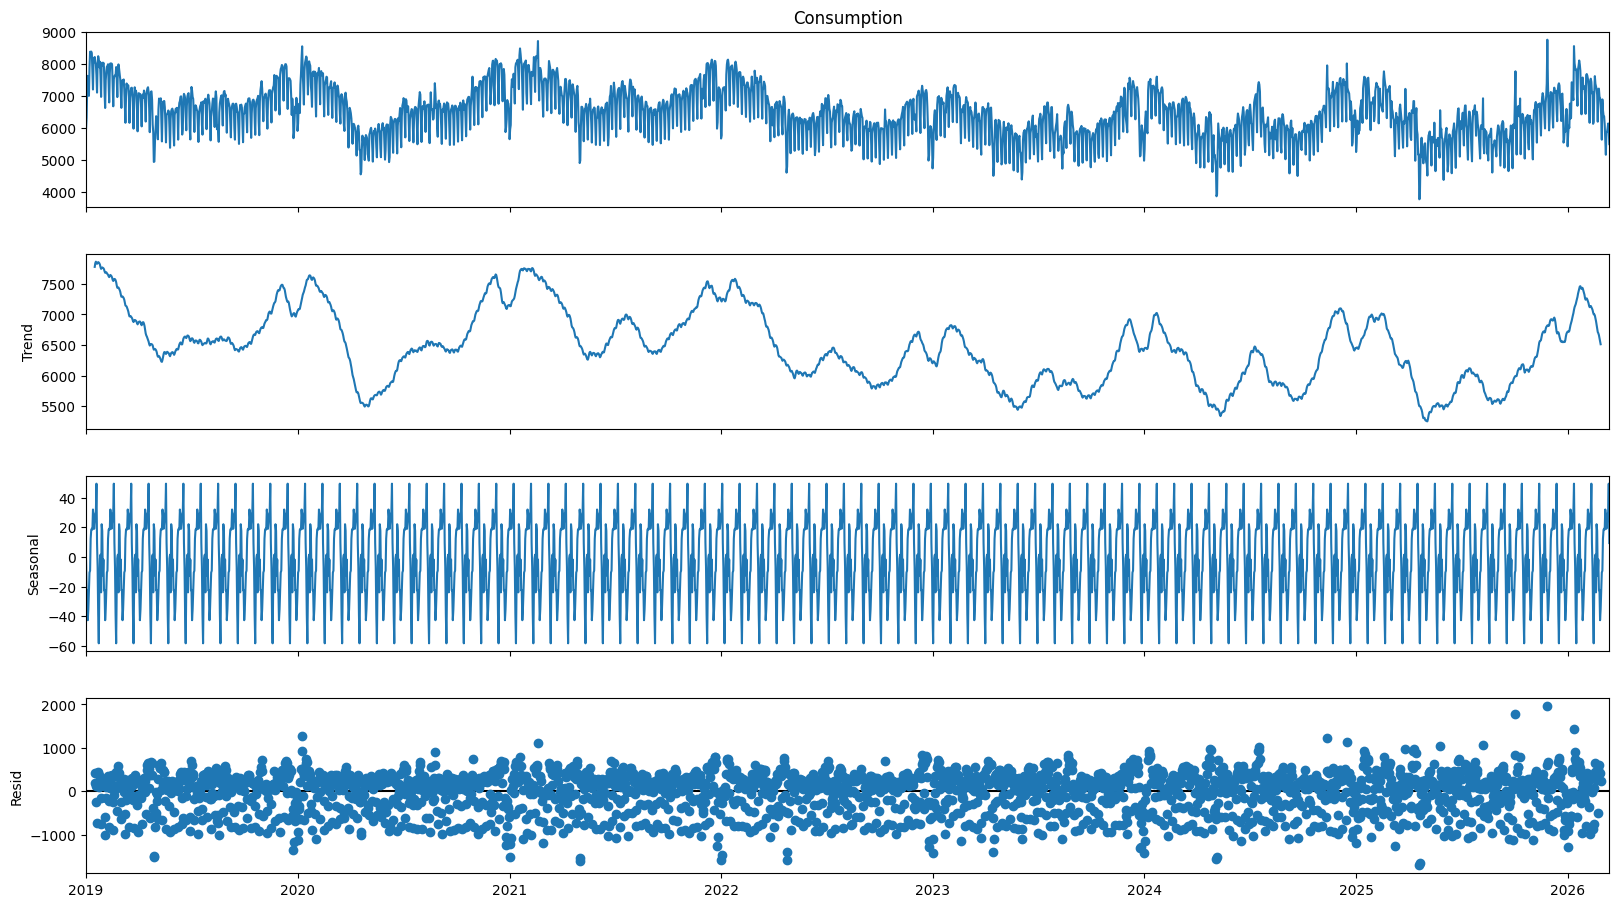

In [ ]:
decomposition = seasonal_decompose(pd_series, model = 'additive', period = 30)
fig = decomposition.plot()
fig.set_size_inches(18, 10)
plt.show()

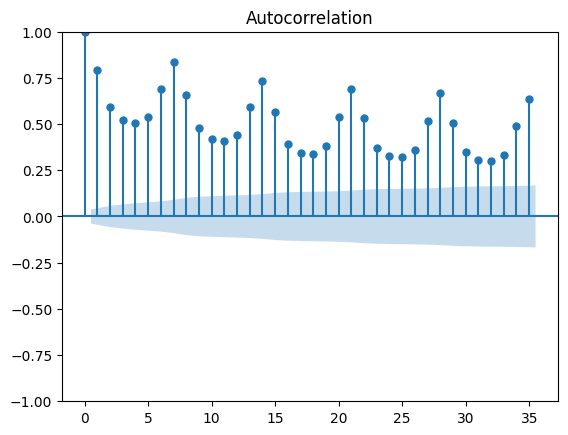

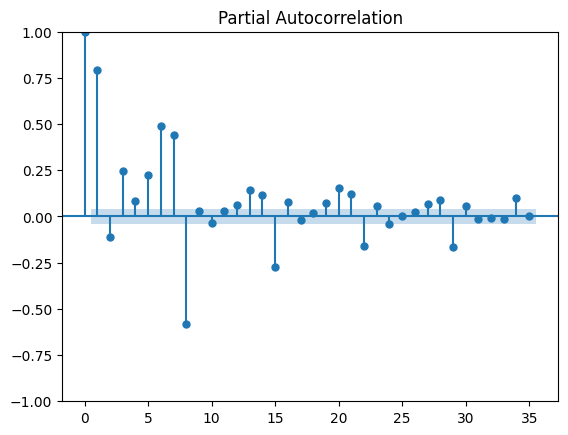

In [ ]:
plot_acf(pd_series)
plot_pacf(pd_series)
plt.show()

In [ ]:
def adf_stationarity_test(pd_series: pd.Series) -> dict:
    pd_series = pd_series.dropna()
    result = adfuller(pd_series)
    p_value = result[1]
    return {"ADF Statistic": round(result[0], 4), "p-value": round(p_value, 4),
            "Stationary": p_value < 0.05}

adf_results = {name: adf_stationarity_test(s) for name, s in data.items()}
pd.DataFrame(adf_results)

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
ADF Statistic,-4.2189,-3.9217,-7.0671,-7.4108,-4.0639,-4.5497,-3.0504,-2.6826,-3.8998
p-value,0.0006,0.0019,0.0,0.0,0.0011,0.0002,0.0304,0.0771,0.002
Stationary,True,True,True,True,True,True,True,False,True


In [ ]:
series = TimeSeries.from_series(pd_series)

##Using models

In [ ]:
def plot_residual_diagnostics(actual_series, forecast_series, model_name="Model"):
    res_series = actual_series - forecast_series

    residuals = res_series.values().flatten()
    residuals_clean = residuals[~np.isnan(residuals)]

    fig, axes = plt.subplots(1, 2, figsize=(18, 4))

    axes[0].plot(residuals_clean, color='crimson', lw=1.5)
    axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
    axes[0].set_title(f"{model_name}: Залишки в часі")
    axes[0].grid(alpha=0.3)

    plot_acf(residuals_clean, lags=min(14, len(residuals_clean) - 1), ax=axes[1], color='darkblue')
    axes[1].set_title(f"{model_name}: ACF залишків")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_model(model_cls, model_kwargs, series, horizons = [15, 30, 45], model_name = 'Model'):
  results = []
  for horizon in horizons:
    train, test = series.split_before(len(series) - horizon)
    model = model_cls(**model_kwargs)
    t_start_fit = time.perf_counter()
    model.fit(train)
    fit_duration = time.perf_counter() - t_start_fit

    t_start_pred = time.perf_counter()
    forecast = model.predict(horizon)
    pred_duration = time.perf_counter() - t_start_pred

    mape_val = round(mape(test, forecast), 2)
    mse_val = round(mse(test, forecast), 2)
    mae_val = round(mae(test, forecast), 2)

    results.append({'Model': model_name, 'Horizon (Days)': horizon, 'MAPE': mape_val, 'MAE': mae_val, 'MSE': mse_val})

    plt.figure(figsize=(12, 4))
    train[-120:].plot(label="Train")
    test.plot(label="Actual")
    forecast.plot(label="Forecast")
    plt.title(f"{model_name} Forecast ({horizon} Days) [Fit: {fit_duration:.3f}s | Predict: {pred_duration:.3f}s]")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plot_residual_diagnostics(test, forecast, model_name=f"{model_name} (Horizon {horizon})")

  return pd.DataFrame(results)

In [ ]:
def run_optuna_study(objective_func, n_trials=20, seed = 10):
  study = optuna.create_study(direction = 'minimize', sampler=optuna.samplers.TPESampler(seed = seed))
  study.optimize(objective_func, n_trials=n_trials, show_progress_bar = True)

  print(f"\nBest MAPE: {round(study.best_value, 2)}")
  print(f"Best params: {study.best_params}\n")
  return study.best_params

###Using ARIMA model

[I 2026-08-18 14:21:10,458] A new study created in memory with name: no-name-b2591c57-b6e1-4c1f-be8a-7bdf7fc006f9


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-18 14:21:10,491] Trial 0 finished with value: inf and parameters: {'p': 3, 'd': 1, 'q': 2, 'P': 2, 'D': 0, 'Q': 0}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:10,508] Trial 1 finished with value: inf and parameters: {'p': 0, 'd': 2, 'q': 0, 'P': 0, 'D': 1, 'Q': 2}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:10,529] Trial 2 finished with value: inf and parameters: {'p': 0, 'd': 2, 'q': 3, 'P': 1, 'D': 1, 'Q': 0}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:10,538] Trial 3 finished with value: inf and parameters: {'p': 3, 'd': 2, 'q': 2, 'P': 0, 'D': 0, 'Q': 2}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:10,546] Trial 4 finished with value: inf and parameters: {'p': 1, 'd': 1, 'q': 2, 'P': 1, 'D': 1, 'Q': 1}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:10,556] Trial 5 finished with value: inf and parameters: {'p': 3, 'd': 2, 'q': 3, 'P': 0, 'D': 0, 'Q': 0}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:10,582] Trial 6 fini

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


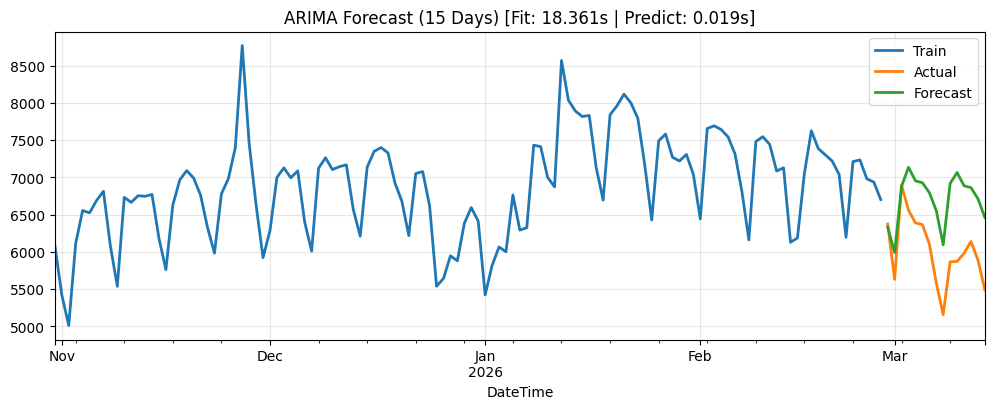

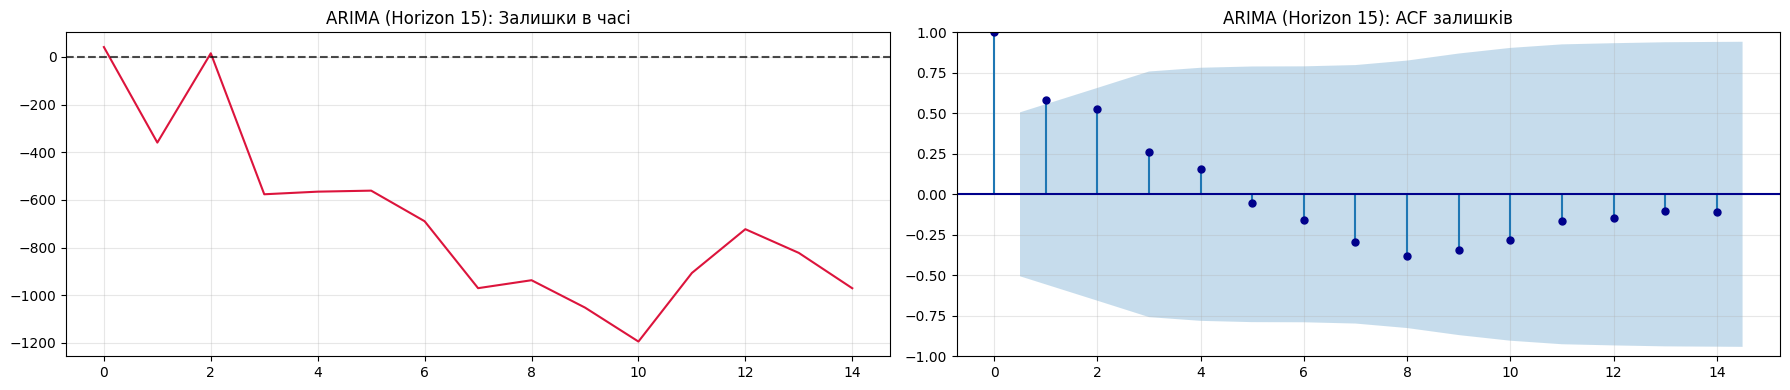

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


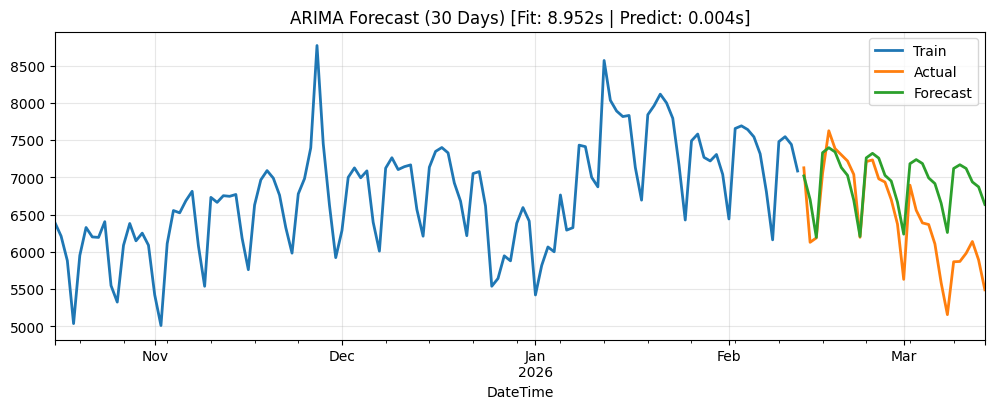

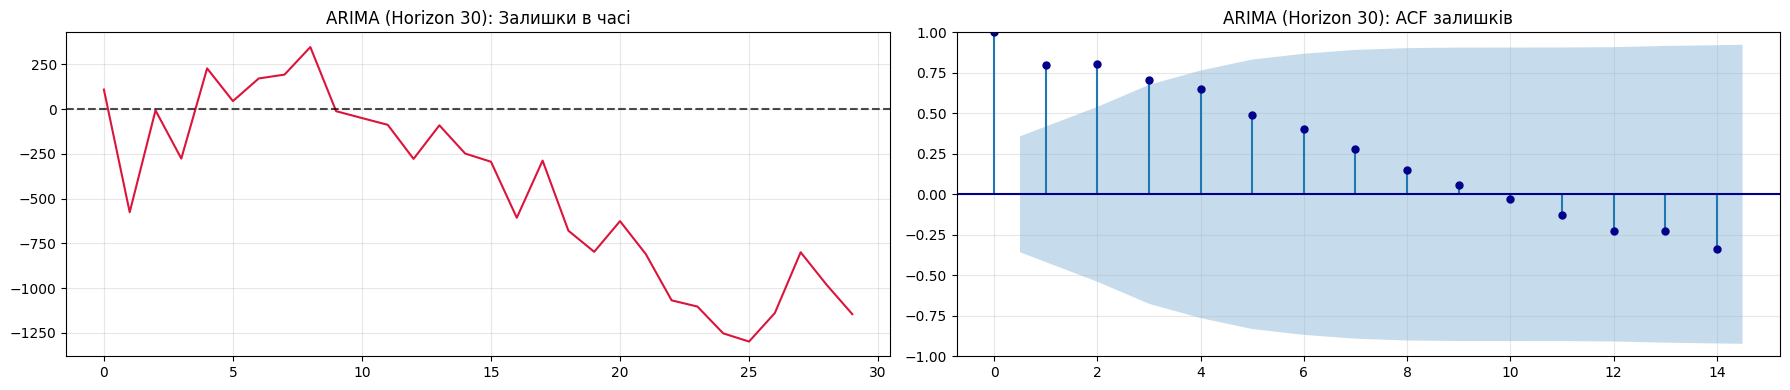

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


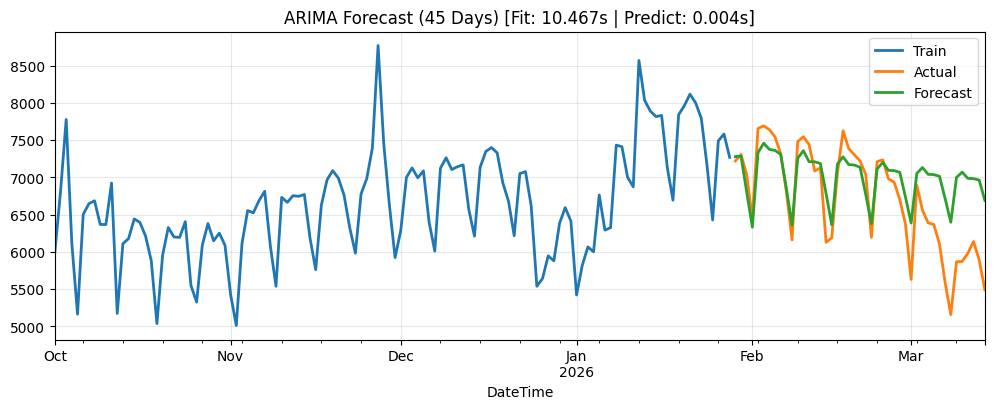

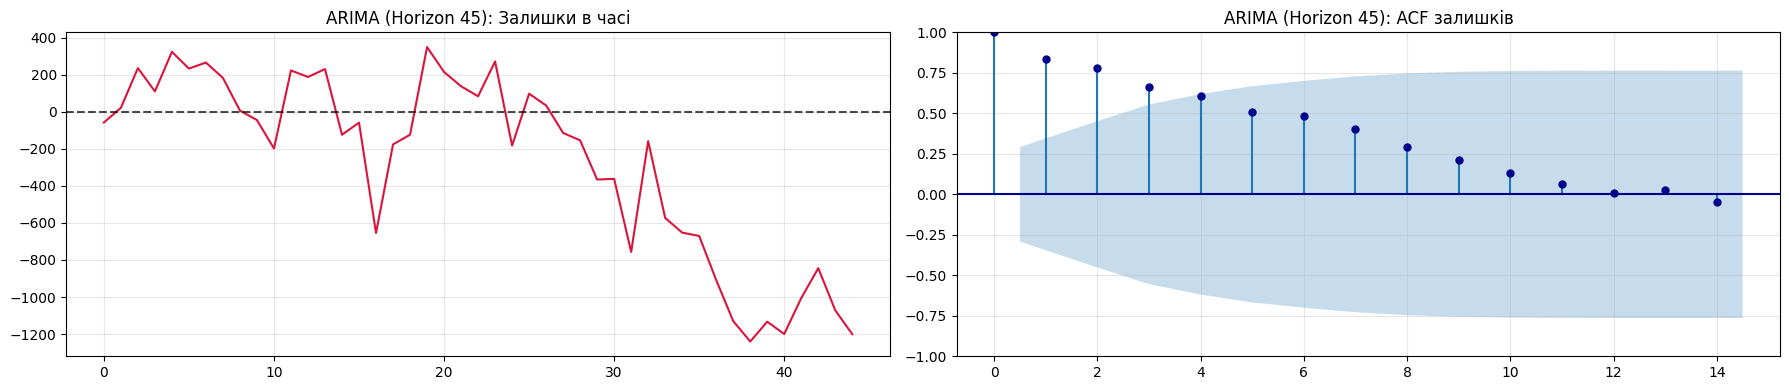

,Model,Horizon (Days),MAPE,MAE,MSE
0,ARIMA,15,11.83,692.57,592993.54
1,ARIMA,30,8.62,520.29,444270.14
2,ARIMA,45,6.64,408.34,313417.92


In [ ]:
def arima_obj(trial):
    try:
        model = ARIMA(
            p=trial.suggest_int("p", 0, 3),
            d=trial.suggest_int("d", 1, 2),
            q=trial.suggest_int("q", 0, 3),
            seasonal_order=(trial.suggest_int("P", 0, 2), trial.suggest_int("D", 0, 1), trial.suggest_int("Q", 0, 2),7))
        model.fit(train)
        return mape(val, model.predict(len(val)))
    except:
        return float("inf")

best_arima_params = run_optuna_study(arima_obj, n_trials=20)

arima_kwargs = {
    "p": best_arima_params["p"],
    "d": best_arima_params["d"],
    "q": best_arima_params["q"],
    "seasonal_order": (best_arima_params["P"], best_arima_params["D"], best_arima_params["Q"], 7)}

df_arima = evaluate_model(ARIMA, arima_kwargs, series, model_name="ARIMA")
df_arima

###Prophet

[I 2026-08-18 14:21:52,575] A new study created in memory with name: no-name-f5ac7522-7bba-45bf-819d-bbb13eff720b


  0%|          | 0/20 [00:00<?, ?it/s]

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


[I 2026-08-18 14:21:52,595] Trial 0 finished with value: inf and parameters: {'changepoint_prior_scale': 0.020438576111012248, 'seasonality_prior_scale': 0.011541329711371683}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:52,598] Trial 1 finished with value: inf and parameters: {'changepoint_prior_scale': 0.01192749778115605, 'seasonality_prior_scale': 1.7636469336159117}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:52,603] Trial 2 finished with value: inf and parameters: {'changepoint_prior_scale': 0.007029888889425128, 'seasonality_prior_scale': 0.04724870791526791}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:52,607] Trial 3 finished with value: inf and parameters: {'changepoint_prior_scale': 0.0021702155262233926, 'seasonality_prior_scale': 1.912459014251738}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:52,614] Trial 4 finished with value: inf and parameters: {'changepoint_prior_scale': 0.001937823591174791, 'seasonality_prior_scale': 0.0184085441

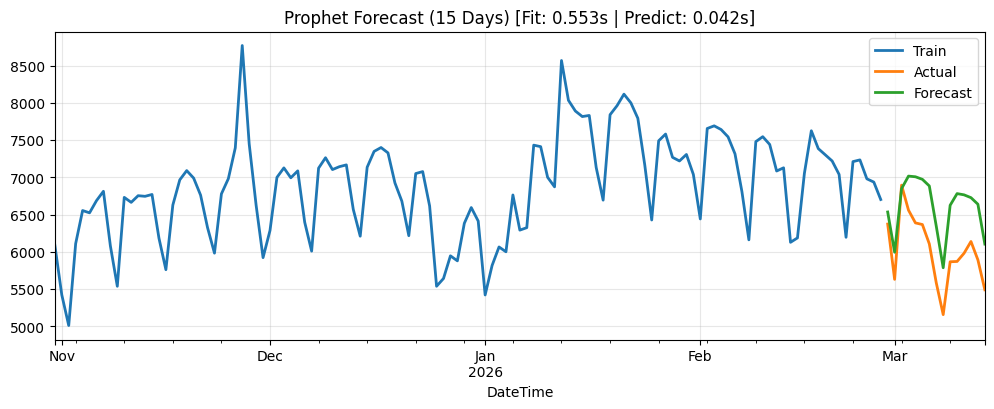

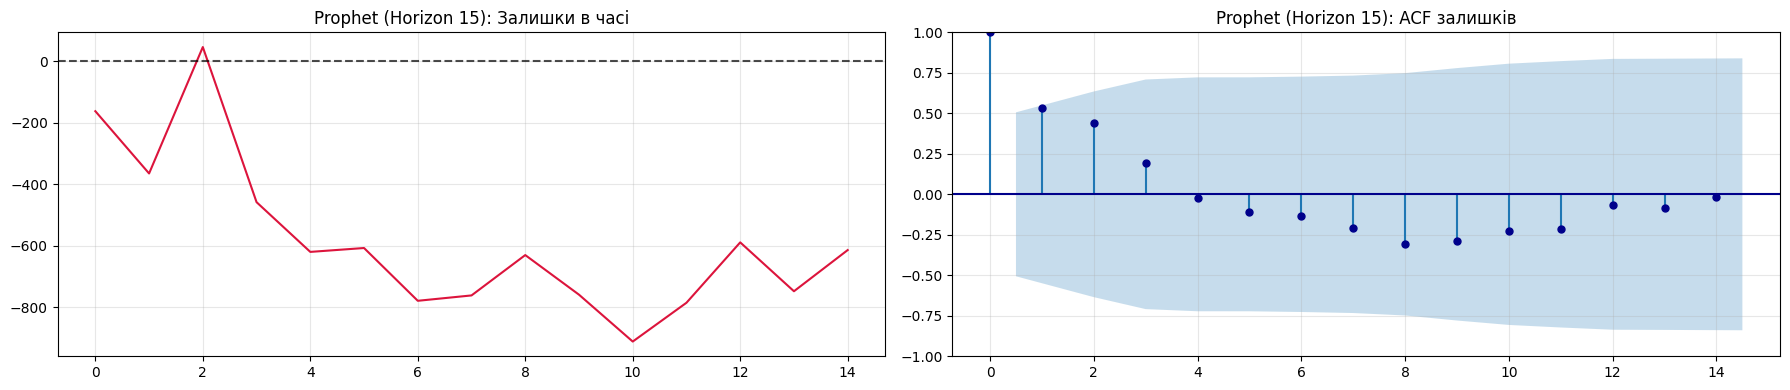

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


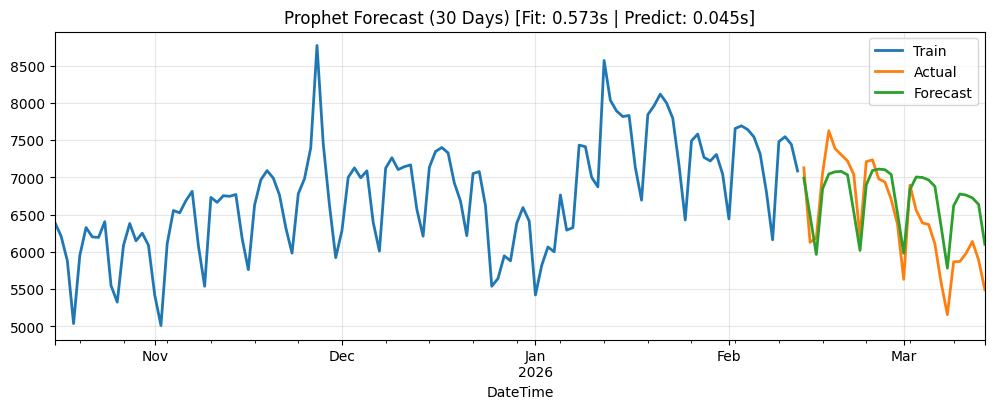

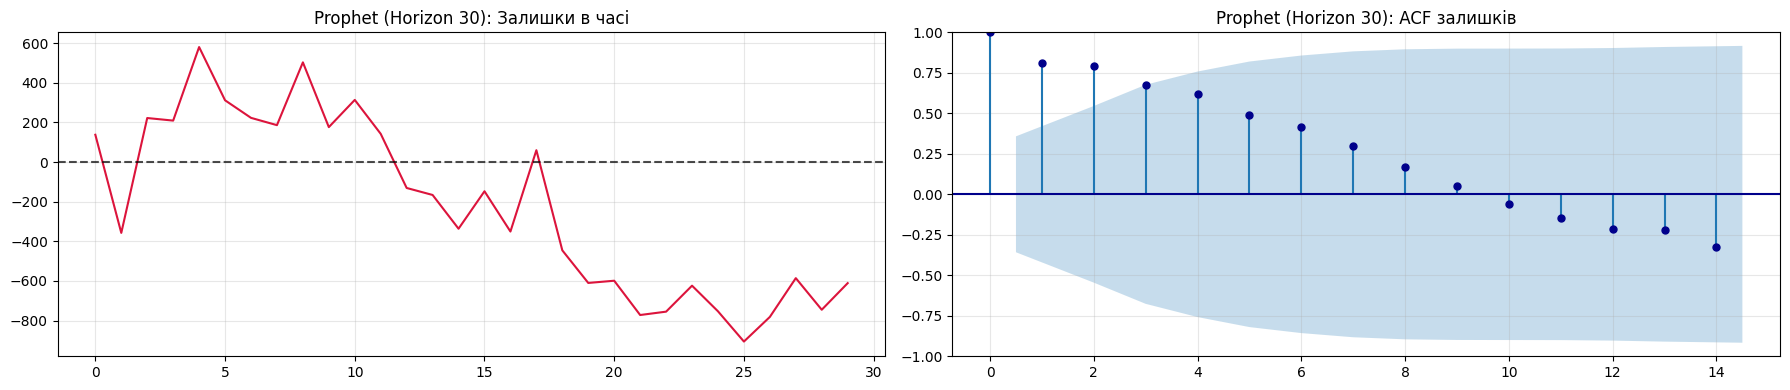

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


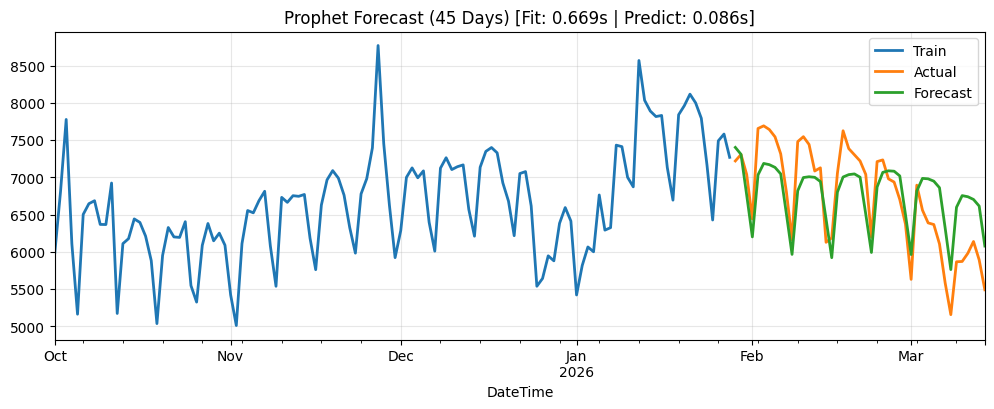

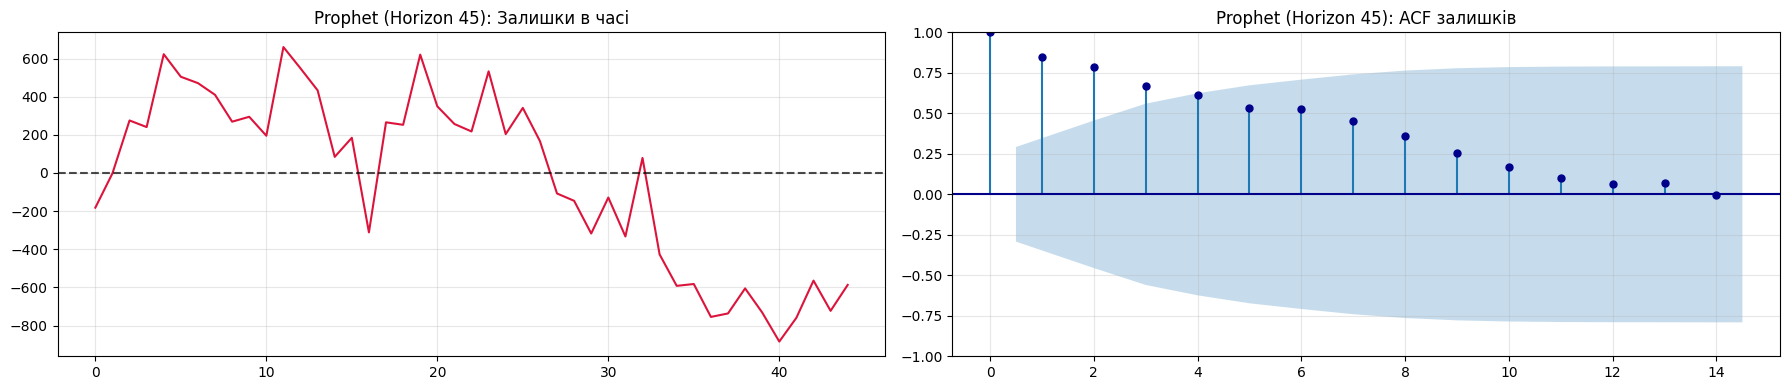

,Model,Horizon (Days),MAPE,MAE,MSE
0,Prophet,15,9.97,588.73,400550.87
1,Prophet,30,6.85,424.67,240664.96
2,Prophet,45,6.13,399.19,208605.91


In [ ]:
def prophet_obj(trial):
    try:
        model = Prophet(
            changepoint_prior_scale=trial.suggest_float("changepoint_prior_scale", 0.001, 0.05, log=True),
            seasonality_prior_scale=trial.suggest_float("seasonality_prior_scale", 0.01, 10.0, log=True),
            seasonality_mode="additive"
        )
        model.fit(train)
        return mape(val, model.predict(len(val)))
    except:
        return float("inf")

best_prophet_params = run_optuna_study(prophet_obj, n_trials=20)

prophet_kwargs = {
    "changepoint_prior_scale": best_prophet_params["changepoint_prior_scale"],
    "seasonality_prior_scale": best_prophet_params["seasonality_prior_scale"],
    "seasonality_mode": "additive"
}

df_prophet = evaluate_model(Prophet, prophet_kwargs, series, model_name="Prophet")
df_prophet

###XGBoost

[I 2026-08-18 14:21:56,761] A new study created in memory with name: no-name-f1b67379-9fb1-49d7-b624-32220d7c5129


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-18 14:21:56,782] Trial 0 finished with value: inf and parameters: {'lags': 26, 'n_estimators': 55, 'max_depth': 6, 'learning_rate': 0.12766567050674044, 'subsample': 0.7994028049210362}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:56,788] Trial 1 finished with value: inf and parameters: {'lags': 12, 'n_estimators': 99, 'max_depth': 7, 'learning_rate': 0.017774492563555844, 'subsample': 0.6353359256696041}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:56,794] Trial 2 finished with value: inf and parameters: {'lags': 24, 'n_estimators': 289, 'max_depth': 2, 'learning_rate': 0.05709131925970865, 'subsample': 0.9250483846608454}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:56,799] Trial 3 finished with value: inf and parameters: {'lags': 22, 'n_estimators': 231, 'max_depth': 4, 'learning_rate': 0.22681076499740013, 'subsample': 0.8858303133590761}. Best is trial 0 with value: inf.
[I 2026-08-18 14:21:56,807] Trial 4 finished with value: inf and paramete

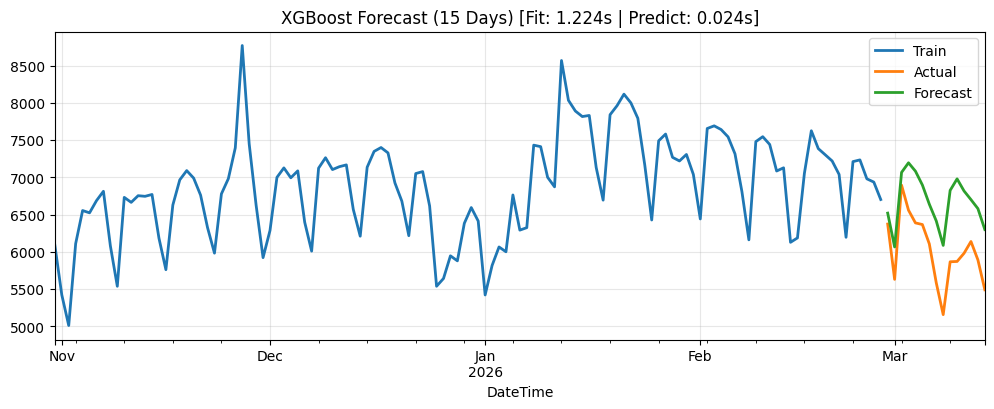

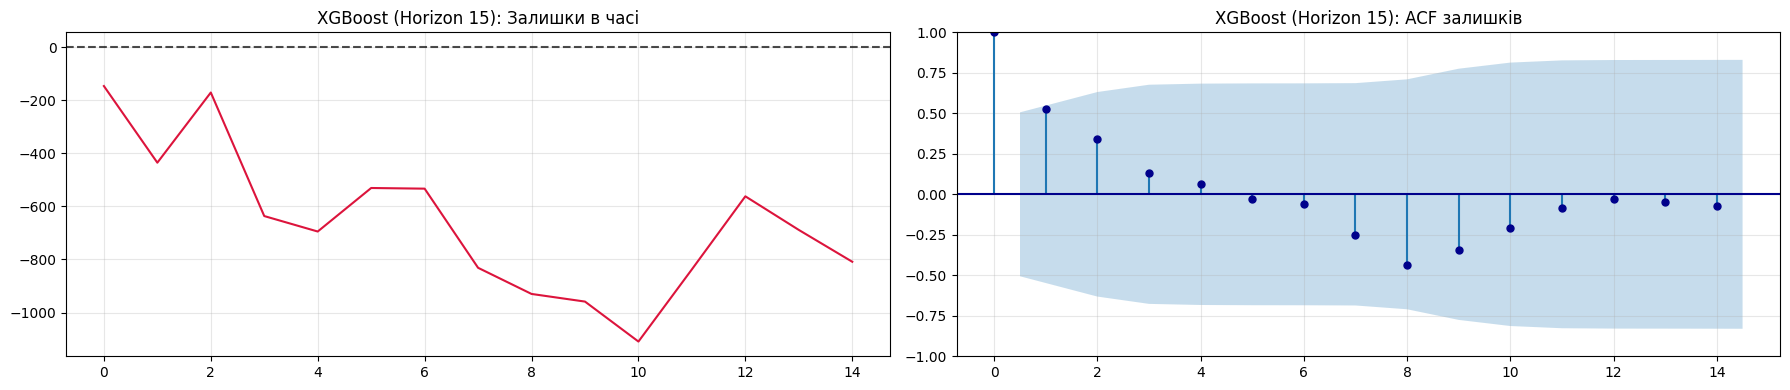

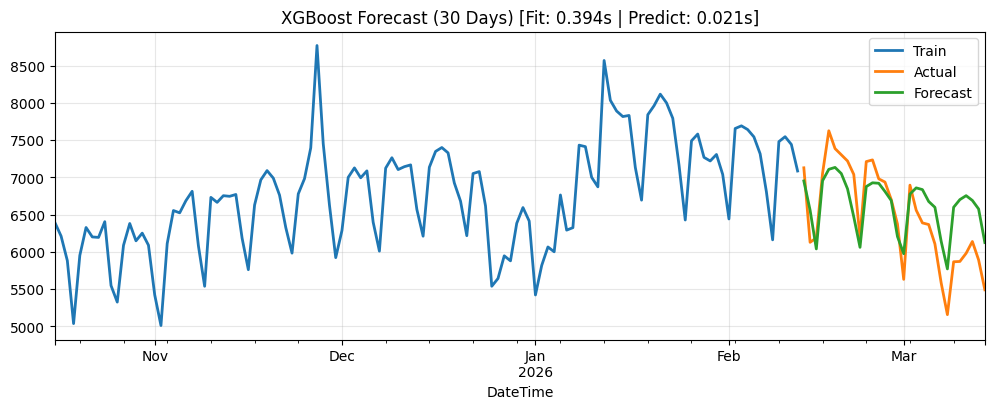

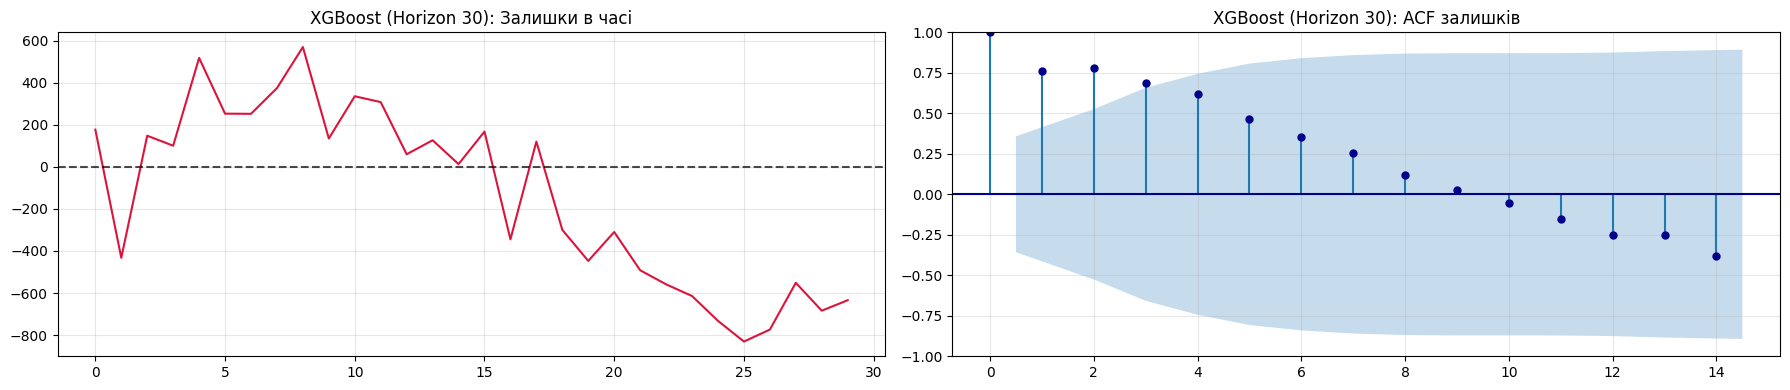

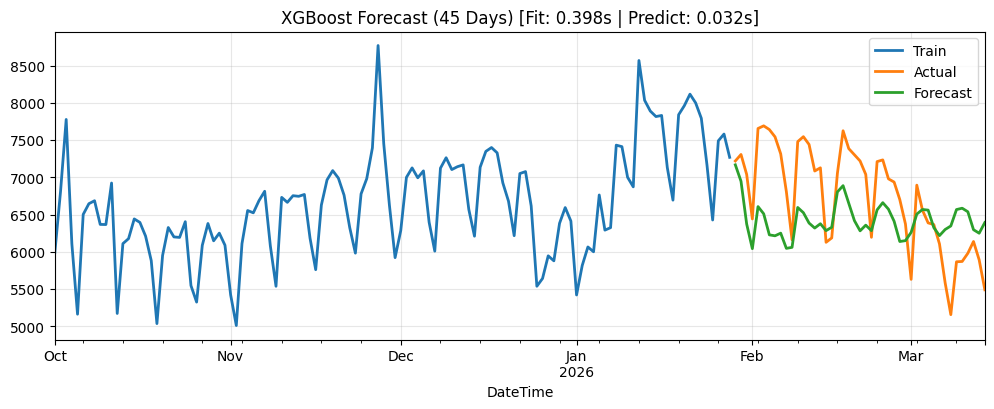

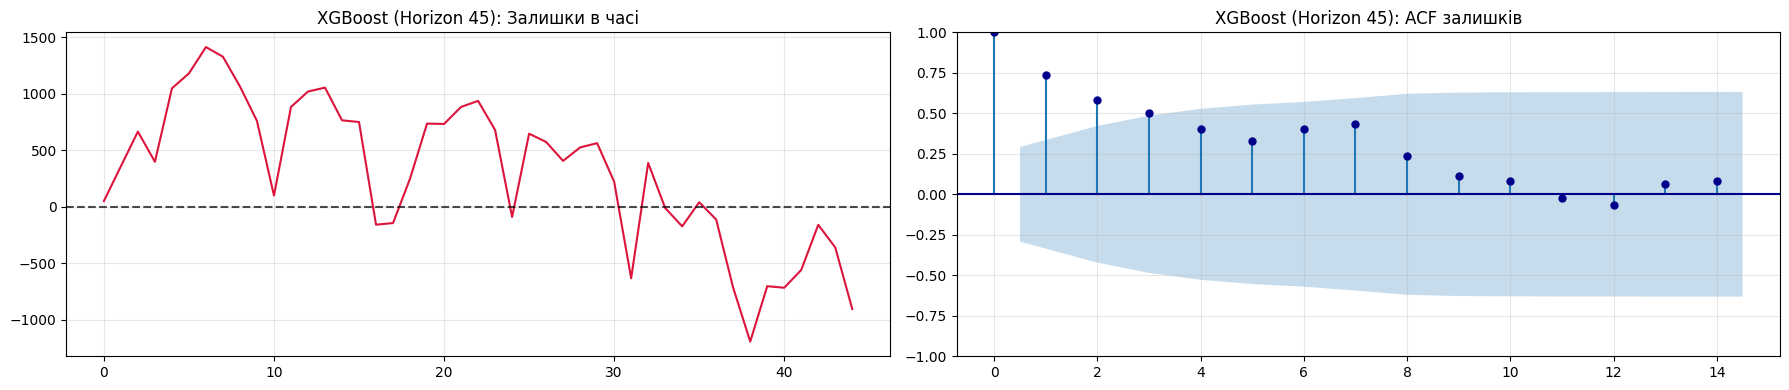

,Model,Horizon (Days),MAPE,MAE,MSE
0,XGBoost,15,11.19,658.27,502925.41
1,XGBoost,30,6.09,378.65,194384.43
2,XGBoost,45,8.84,601.45,499974.46


In [ ]:
def xgb_obj(trial):
    try:
        model = XGBModel(
            lags=trial.suggest_int("lags", 7, 31),
            n_estimators=trial.suggest_int("n_estimators", 50, 300),
            max_depth=trial.suggest_int("max_depth", 2, 8),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            random_state=42
        )
        model.fit(train)
        return mape(val, model.predict(n=len(val)))
    except:
        return float("inf")

best_xgb_params = run_optuna_study(xgb_obj, n_trials=20)

xgb_kwargs = {
    "lags": best_xgb_params["lags"],
    "n_estimators": best_xgb_params["n_estimators"],
    "max_depth": best_xgb_params["max_depth"],
    "learning_rate": best_xgb_params["learning_rate"],
    "subsample": best_xgb_params["subsample"],
    "random_state": 42
}

df_xgb = evaluate_model(XGBModel, xgb_kwargs, series, model_name="XGBoost")
df_xgb

### LinearRegressionModel

[I 2026-08-18 14:22:01,346] A new study created in memory with name: no-name-b4eb8ddd-0df3-48ff-ada9-7eb8b0c779f1


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-18 14:22:01,366] Trial 0 finished with value: inf and parameters: {'lags': 26}. Best is trial 0 with value: inf.
[I 2026-08-18 14:22:01,372] Trial 1 finished with value: inf and parameters: {'lags': 7}. Best is trial 0 with value: inf.
[I 2026-08-18 14:22:01,379] Trial 2 finished with value: inf and parameters: {'lags': 22}. Best is trial 0 with value: inf.
[I 2026-08-18 14:22:01,385] Trial 3 finished with value: inf and parameters: {'lags': 25}. Best is trial 0 with value: inf.
[I 2026-08-18 14:22:01,390] Trial 4 finished with value: inf and parameters: {'lags': 19}. Best is trial 0 with value: inf.
[I 2026-08-18 14:22:01,394] Trial 5 finished with value: inf and parameters: {'lags': 12}. Best is trial 0 with value: inf.
[I 2026-08-18 14:22:01,398] Trial 6 finished with value: inf and parameters: {'lags': 11}. Best is trial 0 with value: inf.
[I 2026-08-18 14:22:01,402] Trial 7 finished with value: inf and parameters: {'lags': 26}. Best is trial 0 with value: inf.
[I 2026-0

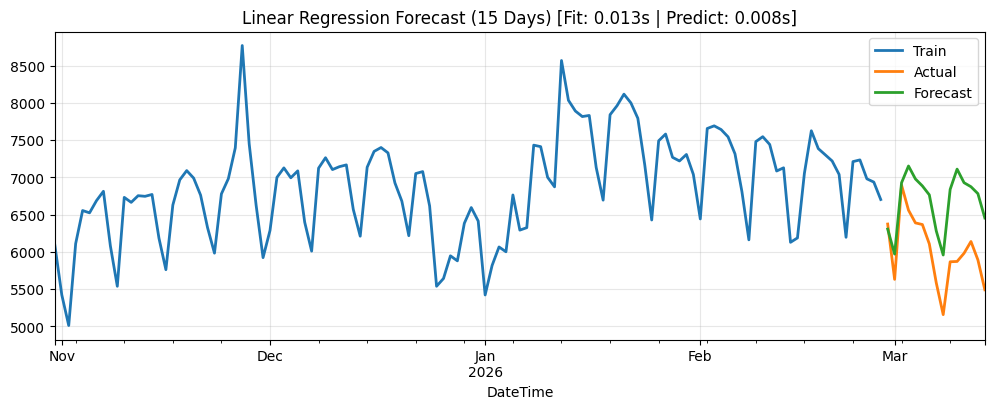

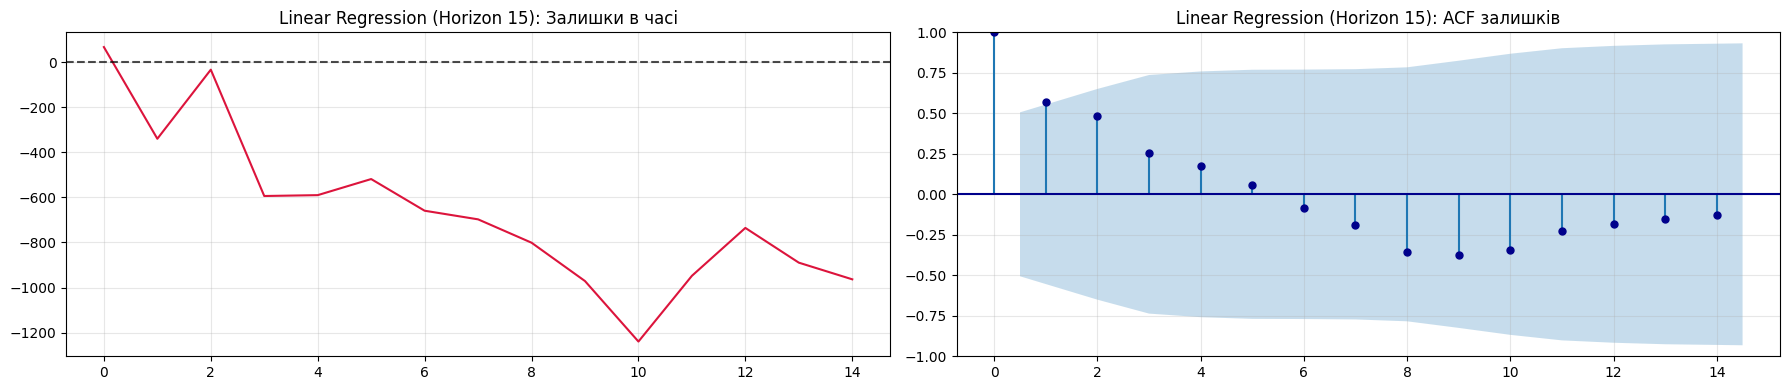

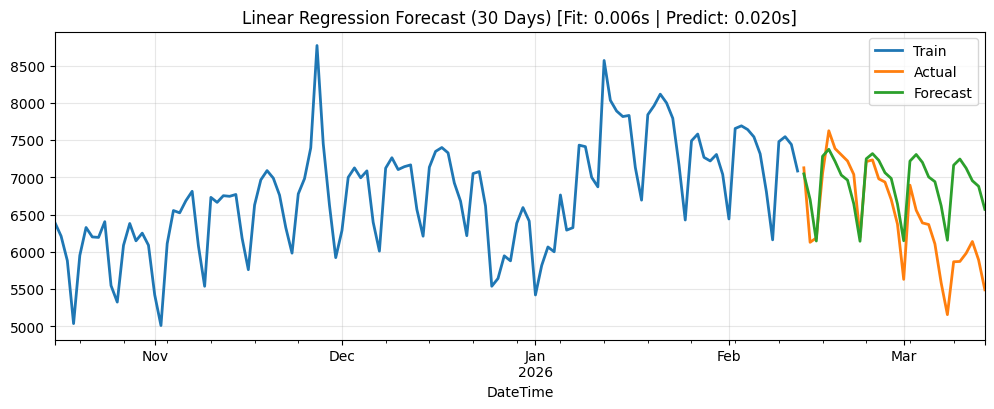

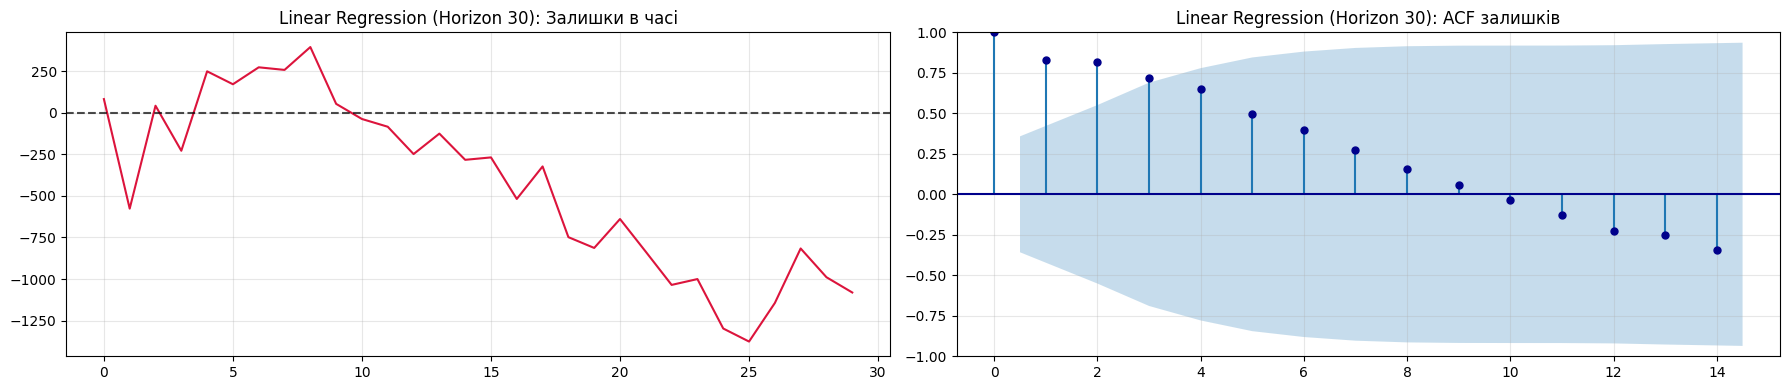

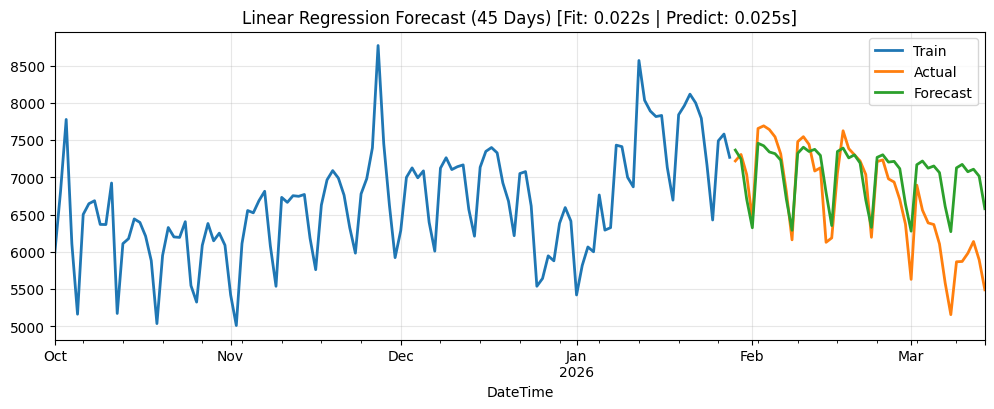

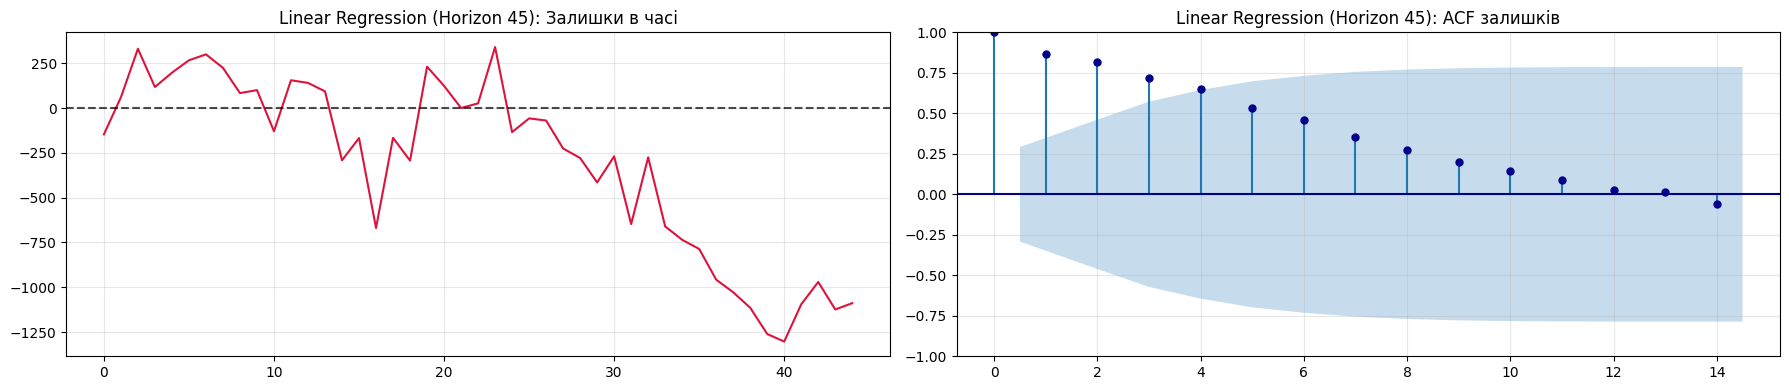

,Model,Horizon (Days),MAPE,MAE,MSE
0,Linear Regression,15,11.40,669.76,552800.42
1,Linear Regression,30,8.78,532.90,449484.51
2,Linear Regression,45,6.89,425.78,331803.11


In [ ]:
def linreg_obj(trial):
    try:
        model = LinearRegressionModel(
            lags=trial.suggest_int("lags", 7, 31),
            random_state=42
        )
        model.fit(train)
        return mape(val, model.predict(n=len(val)))
    except:
        return float("inf")

best_linreg_params = run_optuna_study(linreg_obj, n_trials=20)

linreg_kwargs = {
    "lags": best_linreg_params["lags"],
    "random_state": 42
}

df_linreg = evaluate_model(LinearRegressionModel, linreg_kwargs, series, model_name="Linear Regression")
df_linreg

###Results

In [ ]:
all_results = pd.concat([df_arima, df_prophet, df_xgb, df_linreg], ignore_index=True)

summary_table = all_results.sort_values(by=["Horizon (Days)", "MAPE"]).reset_index(drop=True)
summary_table

,Model,Horizon (Days),MAPE,MAE,MSE
0,Prophet,15,9.97,588.73,400550.87
1,XGBoost,15,11.19,658.27,502925.41
2,Linear Regression,15,11.40,669.76,552800.42
3,ARIMA,15,11.83,692.57,592993.54
4,XGBoost,30,6.09,378.65,194384.43
5,Prophet,30,6.85,424.67,240664.96
6,ARIMA,30,8.62,520.29,444270.14
7,Linear Regression,30,8.78,532.90,449484.51
8,Prophet,45,6.13,399.19,208605.91
9,ARIMA,45,6.64,408.34,313417.92


####Project Conclusions and Performance Analysis
#####1. Benchmark Overview and Accuracy Trade-Offs
The comparative benchmark evaluated four distinct time series paradigms across 15-, 30-, and 45-day horizons:

*   Decomposition (Prophet): Prophet demonstrated superior performance on both the short-term (15-day MAPE: 9.97%) and long-term (45-day MAPE: 6.13%) horizons. Its built-in Fourier terms and flexible changepoint mechanism effectively handled multi-scale seasonality without accumulating compounding autoregressive errors. However, this accuracy comes at the cost of higher runtime complexity (0.042s - 0.086s).
* Gradient Boosting (XGBoost): XGBoost achieved the best overall metric score across the entire study on the 30-day horizon (MAPE: 6.09%, MSE: 194,384.43). Its fast execution (0.021s - 0.032s) makes it an ideal candidate for production environments requiring frequent re-training and low-latency predictions. On the 45-day horizon, its performance slightly degraded (MAPE: 8.84%).
* Statistical & Linear Baselines (ARIMA & Linear Regression): Linear Regression served as a fast baseline (0.008s - 0.025s), achieving reasonable results (MAPE 6.89% - 11.40%) but struggling to capture non-linear peaks. ARIMA provided stable results across intermediate horizons (MAPE: 8.62% on 30 days and 6.64% on 45 days) with ultra-fast inference (0.004s), though it lagged behind Prophet on seasonal adaptation.


#####2. Horizon Sensitivity and Seasonality Drops
Across all four models, the highest MAPE values were observed on the 15-day test horizon (ranging from 9.97% to 11.83%). This phenomenon was driven by a seasonal drop in electricity consumption during that specific evaluation window, which induced temporary positive forecast bias before the models re-adjusted on the 30- and 45-day windows.
#####3. Practical Recommendations
* Operational / Near-Real-Time Load Balancing (1–30 Days): Deploy XGBoost due to its optimal speed-to-accuracy ratio and strong performance on medium windows.
*   Strategic & Long-Term Grid Planning (30–45+ Days): Deploy Prophet to ensure robust seasonal generalization and prevent drift on long forecast horizons.
